<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [6]:
df=pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(240)

In [12]:
print("Dublikatlar soni:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Yangi shape:", df.shape)

Dublikatlar soni: 240
Yangi shape: (1359, 12)


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['quality_label'] = (df['quality'] >= 7).astype(int)

In [15]:
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# DECISION TREE

In [24]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

y_pred=dt.predict(X_test)

In [25]:
print("Decision Tree:")
print(classification_report(y_test, y_pred))

Decision Tree:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       235
           1       0.40      0.49      0.44        37

    accuracy                           0.83       272
   macro avg       0.66      0.69      0.67       272
weighted avg       0.85      0.83      0.84       272



# RANDOM FOREST

In [26]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

In [27]:
print("Random Forest Classifier:")
print(classification_report(y_test,y_pred_rf))

Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       235
           1       0.72      0.35      0.47        37

    accuracy                           0.89       272
   macro avg       0.81      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272



Top 5 significant characters:
alcohol             0.171173
sulphates           0.127573
volatile acidity    0.100928
density             0.089219
citric acid         0.080875
dtype: float64


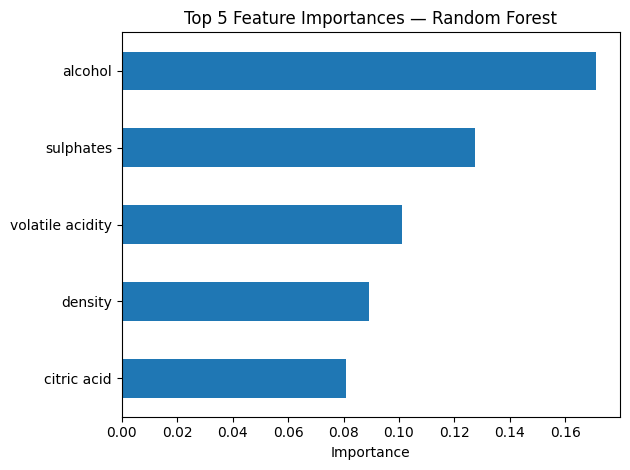

In [28]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top5 = importances.sort_values(ascending=False).head(5)

print("Top 5 significant characters:")
print(top5)

top5.plot(kind='barh')
plt.title("Top 5 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# MIDDLE LEVEL

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [37]:
df1 = pd.read_csv("https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv")

df1 = df1.drop_duplicates().reset_index(drop=True)
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [38]:

X = df1.drop(columns=['target'])
y = df1['target']

numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

max_depth_range = range(1, 21)
train_scores = []
test_scores = []

              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



In [41]:
max_depth_range = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depth_range:
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(max_depth=depth, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test, pipe.predict(X_test)))


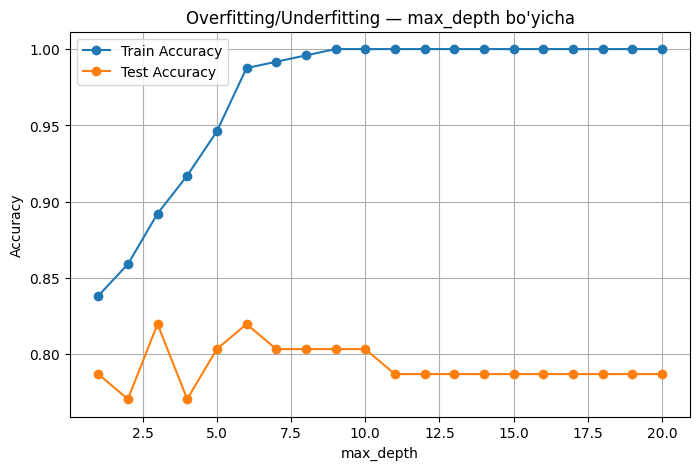

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(max_depth_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(max_depth_range, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting/Underfitting — max_depth bo\'yicha')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
min_split_range = range(2, 21)
train_scores2 = []
test_scores2 = []

for ms in min_split_range:
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(min_samples_split=ms, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_scores2.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores2.append(accuracy_score(y_test, pipe.predict(X_test)))

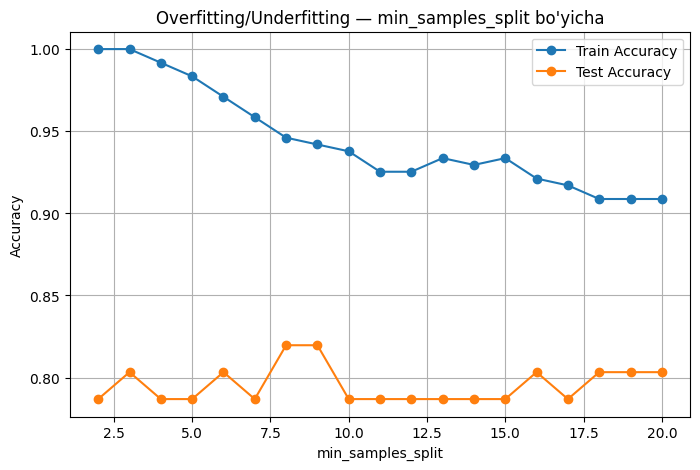

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(min_split_range, train_scores2, label='Train Accuracy', marker='o')
plt.plot(min_split_range, test_scores2, label='Test Accuracy', marker='o')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Overfitting/Underfitting — min_samples_split bo\'yicha')
plt.legend()
plt.grid(True)
plt.show()